# Notebook 08 — Counterfactual Shadow Policy

**Paper**: Guéant, O. (2017). *Optimal Market Making*.
**Status**: **Innovation extension** — not in the paper. Introduces Bayesian belief tracking over latent microstructure regimes with stress-distorted quote blending.

**Figures produced**:

| Figure | Content |
|--------|---------|
| 1 | True latent world + posterior belief evolution (sample path) |
| 2 | Sample-path spread and inventory comparison (Static vs Shadow vs Oracle) |
| 3 | Terminal P&L distributions |

---

## Motivation

Notebook 07 showed that adapting to regimes improves performance — but assumed the market maker **knows** when regimes change. In practice, regimes are **latent**: the market maker must **infer** the current microstructure from observables (price moves, fill events).

This notebook introduces a **shadow policy** that:
1. Maintains a **posterior belief** $\pi_t(j)$ over candidate "worlds" $j \in \{1, \ldots, W\}$.
2. Updates beliefs via **Bayesian filtering** on observed price increments and fill/no-fill events.
3. Blends world-specific optimal quotes using a **stress-distorted** weighted average.

We compare three policies:
- **Static**: Always uses baseline-world quotes (no adaptation).
- **Shadow**: Bayesian belief-weighted blend with stress tilt.
- **Oracle**: Knows the true world at each step (upper bound on performance).


## 1. Mathematical framework

### 1.1 Candidate worlds

Each world $j$ defines a microstructure triplet $(A_j, k_j, \sigma_j)$:

| World | $A_j/A_0$ | $k_j/k_0$ | $\sigma_j/\sigma_0$ | Character |
|-------|-----------|-----------|---------------------|-----------|
| Calm | 0.80 | 0.90 | 0.75 | Low vol, less activity |
| Base | 1.00 | 1.00 | 1.00 | Paper's baseline |
| Stressed | 1.35 | 1.20 | 1.45 | High vol, more & steeper LOB |

For each world, we precompute an optimal quote table by solving the ODE with that world's parameters.

### 1.2 Bayesian belief update

At each step, the market maker observes:
- A price increment $\Delta S_t$
- Whether a bid fill occurred ($f^b_t \in \{0, 1\}$) and an ask fill ($f^a_t \in \{0, 1\}$)

The likelihood under world $j$ is:

$$\mathcal{L}_{t,j} = \underbrace{\frac{1}{\sqrt{2\pi\sigma_j^2\,dt}} \exp\!\left(-\frac{(\Delta S_t)^2}{2\sigma_j^2\,dt}\right)}_{\text{price shock likelihood}} \cdot \underbrace{p_{b,j}^{f^b_t}(1-p_{b,j})^{1-f^b_t}}_{\text{bid fill likelihood}} \cdot \underbrace{p_{a,j}^{f^a_t}(1-p_{a,j})^{1-f^a_t}}_{\text{ask fill likelihood}}$$

where $p_{b,j} = A_j e^{-k_j \delta^b} dt$ is the fill probability under world $j$.

Posterior update (Bayes):

$$\pi_{t+1}(j) \propto \pi_t(j) \cdot \mathcal{L}_{t,j}$$

### 1.3 Stress-distorted quote blending

Instead of a simple belief-weighted average, we tilt toward **higher-volatility worlds** for robustness:

$$w_j = \pi_t(j) \cdot \left(\frac{\sigma_j}{\bar{\sigma}}\right)^\eta$$

where $\eta > 0$ is the **stress aversion** parameter (we use $\eta = 1.6$). This ensures the market maker quotes more conservatively when uncertainty is high.

The blended quotes are:

$$\delta^b_{\text{shadow}} = \sum_j \tilde{w}_j \cdot \delta^b_j(t, n), \qquad \tilde{w}_j = \frac{w_j}{\sum_j w_j}$$

### 1.4 True world path (unknown to the policy)

We simulate a regime switch mid-session: Base → Stressed at $t = 0.55T$. The shadow policy must detect this from data.


## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from asset.params import IG, GAMMA, T
from src.ode_solver_1d import solve_general

plt.style.use("seaborn-v0_8")
%matplotlib inline


## 3. Parameters and world definitions

In [2]:

N_T = 360
N_SIM = 350

def build_worlds(base):
    """Define candidate microstructure worlds."""
    return [
        dict(name="Calm",     A=base["A"]*0.80, k=base["k"]*0.90, sigma=base["sigma"]*0.75),
        dict(name="Base",     A=base["A"]*1.00, k=base["k"]*1.00, sigma=base["sigma"]*1.00),
        dict(name="Stressed", A=base["A"]*1.35, k=base["k"]*1.20, sigma=base["sigma"]*1.45),
    ]

worlds = build_worlds(IG)

print(f"N_t:   {N_T}  (dt = {T/N_T:.1f} s)")
print(f"N_sim: {N_SIM}")
print(f"\nCandidate worlds:")
for w in worlds:
    print(f"  {w['name']:<10s}  A={w['A']:.4e}  k={w['k']:.2e}  σ={w['sigma']:.2e}")


N_t:   360  (dt = 20.0 s)
N_sim: 350

Candidate worlds:
  Calm        A=7.2800e-04  k=1.61e+04  σ=4.37e-06
  Base        A=9.1000e-04  k=1.79e+04  σ=5.83e-06
  Stressed    A=1.2285e-03  k=2.15e+04  σ=8.45e-06


## 4. Precompute optimal quote tables (one per world)

In [3]:

def precompute_tables(base_params, worlds, gamma, horizon, n_t):
    """Solve one ODE per world → one quote table per world."""
    tables = []
    for w in worlds:
        p = {**base_params, "A": w["A"], "k": w["k"], "sigma": w["sigma"]}
        sol = solve_general(p, gamma, horizon, xi=gamma, N_t=n_t)
        tables.append(dict(delta_bid=sol["delta_bid"], delta_ask=sol["delta_ask"], params=p))
    return tables

print("Precomputing ODE solutions for each world ...")
t0 = time.time()
tables = precompute_tables(IG, worlds, GAMMA, T, N_T)
print(f"  Done in {time.time()-t0:.1f} s ({len(worlds)} worlds × {N_T} steps)")


Precomputing ODE solutions for each world ...
  Done in 0.6 s (3 worlds × 360 steps)


## 5. True world path and simulation engine

In [4]:

def build_true_path(n_t):
    """Base world for first 55%, then Stressed."""
    switch = int(0.55 * n_t)
    idx = np.zeros(n_t, dtype=int)
    idx[:switch] = 1   # Base
    idx[switch:] = 2   # Stressed
    return idx

true_idx = build_true_path(N_T)

print(f"True world path: Base for steps 0–{int(0.55*N_T)-1}, "
      f"Stressed for steps {int(0.55*N_T)}–{N_T-1}")


True world path: Base for steps 0–197, Stressed for steps 198–359


In [5]:

def _safe_log_bernoulli(x, p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return x * np.log(p) + (1 - x) * np.log(1 - p)


def simulate_one(mode, base_params, worlds, tables, true_world_idx_path,
                 horizon, stress_eta=1.6, seed=0):
    """Simulate one trajectory under a given policy mode.

    Modes: 'static' (baseline quotes), 'oracle' (true-world quotes),
           'shadow' (Bayesian belief-blended quotes with stress tilt).
    """
    rng = np.random.default_rng(seed)
    n_t = len(true_world_idx_path)
    dt = horizon / n_t
    times = np.linspace(0.0, horizon, n_t + 1)
    Delta = base_params["Delta"]
    Q = int(base_params["Q"])
    n_worlds = len(worlds)

    S, X, n = 0.0, 0.0, 0
    price = np.zeros(n_t + 1); cash = np.zeros(n_t + 1)
    inv = np.zeros(n_t + 1, dtype=int)
    db_used = np.zeros(n_t); da_used = np.zeros(n_t)
    n_bid_fills = 0; n_ask_fills = 0

    posterior = np.ones(n_worlds) / n_worlds
    posterior_hist = np.zeros((n_t + 1, n_worlds))
    posterior_hist[0] = posterior

    for t_idx in range(n_t):
        i_lot = n + Q
        true_j = int(true_world_idx_path[t_idx])
        true_w = worlds[true_j]

        # ── Select quotes by mode ──
        if mode == "static":
            db = tables[1]["delta_bid"][t_idx, i_lot]
            da = tables[1]["delta_ask"][t_idx, i_lot]
        elif mode == "oracle":
            db = tables[true_j]["delta_bid"][t_idx, i_lot]
            da = tables[true_j]["delta_ask"][t_idx, i_lot]
        elif mode == "shadow":
            cand_db = np.array([tables[j]["delta_bid"][t_idx, i_lot] for j in range(n_worlds)])
            cand_da = np.array([tables[j]["delta_ask"][t_idx, i_lot] for j in range(n_worlds)])
            finite = np.isfinite(cand_db) & np.isfinite(cand_da)
            if not np.any(finite):
                db, da = np.nan, np.nan
            else:
                sig = np.array([w["sigma"] for w in worlds])
                stress = sig / np.mean(sig)
                w = posterior * np.power(stress, stress_eta)
                w = np.where(finite, w, 0.0)
                if np.sum(w) <= 0: w = finite.astype(float)
                w = w / np.sum(w)
                db = float(np.nansum(w * cand_db))
                da = float(np.nansum(w * cand_da))
        else:
            raise ValueError(mode)

        can_bid = (n < Q) and np.isfinite(db)
        can_ask = (n > -Q) and np.isfinite(da)
        db_used[t_idx] = db if np.isfinite(db) else np.nan
        da_used[t_idx] = da if np.isfinite(da) else np.nan

        # ── True market dynamics ──
        dS = true_w["sigma"] * np.sqrt(dt) * rng.standard_normal()
        S += dS

        fill_bid, fill_ask = 0, 0
        if can_bid:
            p_bid = np.clip(true_w["A"] * np.exp(-true_w["k"] * db) * dt, 0, 1)
            fill_bid = int(rng.uniform() < p_bid)
            if fill_bid: n += 1; X -= (S - db) * Delta; n_bid_fills += 1
        if can_ask:
            p_ask = np.clip(true_w["A"] * np.exp(-true_w["k"] * da) * dt, 0, 1)
            fill_ask = int(rng.uniform() < p_ask)
            if fill_ask: n -= 1; X += (S + da) * Delta; n_ask_fills += 1

        # ── Bayes update (shadow mode only) ──
        if mode == "shadow":
            log_like = np.zeros(n_worlds)
            for j, w in enumerate(worlds):
                var = w["sigma"]**2 * dt + 1e-18
                ll = -0.5 * (np.log(2 * np.pi * var) + dS**2 / var)
                if can_bid:
                    ll += _safe_log_bernoulli(fill_bid,
                          np.clip(w["A"] * np.exp(-w["k"] * db) * dt, 1e-12, 1-1e-12))
                if can_ask:
                    ll += _safe_log_bernoulli(fill_ask,
                          np.clip(w["A"] * np.exp(-w["k"] * da) * dt, 1e-12, 1-1e-12))
                log_like[j] = ll
            log_post = np.log(np.clip(posterior, 1e-18, 1.0)) + log_like
            log_post -= np.max(log_post)
            posterior = np.exp(log_post)
            posterior /= np.sum(posterior)

        price[t_idx+1] = S; cash[t_idx+1] = X; inv[t_idx+1] = n
        posterior_hist[t_idx+1] = posterior

    pnl = cash[-1] + inv[-1] * Delta * price[-1]
    mtm = cash + inv * Delta * price
    return dict(pnl=pnl, mtm=mtm, inventory=inv, price=price,
                delta_bid=db_used, delta_ask=da_used,
                posterior=posterior_hist, times=times,
                n_bid_fills=n_bid_fills, n_ask_fills=n_ask_fills)


def simulate_many(mode, n_sim, base_params, worlds, tables,
                  true_world_idx_path, horizon, seed0):
    out = []
    for i in range(n_sim):
        out.append(simulate_one(mode, base_params, worlds, tables,
                                true_world_idx_path, horizon, seed=seed0 + i))
    pnl = np.array([x["pnl"] for x in out])
    n_bid = np.array([x["n_bid_fills"] for x in out], dtype=float)
    n_ask = np.array([x["n_ask_fills"] for x in out], dtype=float)
    return dict(pnl=pnl, n_bid=n_bid, n_ask=n_ask, sample=out[0])


## 6. Run Monte Carlo comparison

In [6]:

print("Running Monte Carlo comparison ...")
t0 = time.time()
res_static = simulate_many("static", N_SIM, IG, worlds, tables, true_idx, T, seed0=100)
res_shadow = simulate_many("shadow", N_SIM, IG, worlds, tables, true_idx, T, seed0=200)
res_oracle = simulate_many("oracle", N_SIM, IG, worlds, tables, true_idx, T, seed0=300)
print(f"  Done in {time.time()-t0:.0f} s  ({3*N_SIM} trajectories total)")

def certainty_equivalent(pnl, gamma):
    max_val = np.max(-gamma * pnl)
    log_E = max_val + np.log(np.mean(np.exp(-gamma * pnl - max_val)))
    return -log_E / gamma

print(f"\n  {'Policy':<8s}  {'Mean':>8s}  {'Std':>8s}  {'Sharpe':>8s}  {'CE':>10s}  {'E[fills]':>10s}")
print("  " + "─" * 58)
for name, res in [("Static", res_static), ("Shadow", res_shadow), ("Oracle", res_oracle)]:
    pnl = res["pnl"]
    mu, sd = np.mean(pnl), np.std(pnl)
    sharpe = mu / max(sd, 1e-12)
    ce = certainty_equivalent(pnl, GAMMA)
    fills = np.mean(res["n_bid"] + res["n_ask"])
    print(f"  {name:<8s}  {mu:>+8.0f}  {sd:>8.0f}  {sharpe:>8.3f}  {ce:>+10.0f}  {fills:>10.2f}")


Running Monte Carlo comparison ...
  Done in 10 s  (1050 trajectories total)

  Policy        Mean       Std    Sharpe          CE    E[fills]
  ──────────────────────────────────────────────────────────
  Static       +8157     13192     0.618       +3839        2.65
  Shadow       +7777     12360     0.629       +3563        2.72
  Oracle       +7019     10363     0.677       +4228        2.51


## 7. Figure 1 — Posterior belief evolution (sample path)

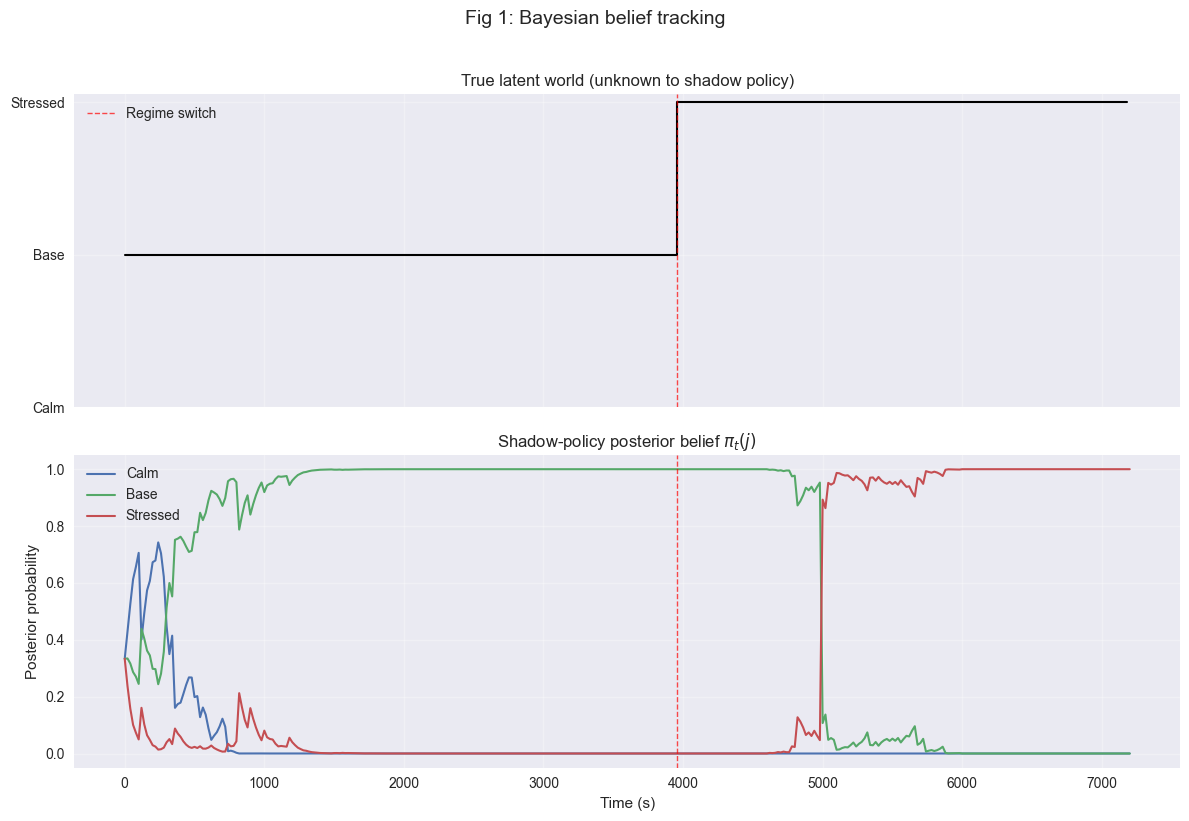

In [7]:

s = res_shadow["sample"]
times_plot = s["times"]
t_mid = times_plot[:-1]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].step(t_mid, true_idx, where="post", lw=1.5, color="k")
axes[0].set_yticks([0, 1, 2], labels=[w["name"] for w in worlds])
axes[0].set_title("True latent world (unknown to shadow policy)")
axes[0].axvline(times_plot[int(0.55*N_T)], color="red", ls="--", lw=1, alpha=0.7,
                label="Regime switch")
axes[0].legend(); axes[0].grid(alpha=0.3)

for j, w in enumerate(worlds):
    axes[1].plot(times_plot, s["posterior"][:, j], lw=1.5, label=w["name"])
axes[1].set_title("Shadow-policy posterior belief $\\pi_t(j)$")
axes[1].set_ylabel("Posterior probability")
axes[1].set_xlabel("Time (s)")
axes[1].axvline(times_plot[int(0.55*N_T)], color="red", ls="--", lw=1, alpha=0.7)
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle("Fig 1: Bayesian belief tracking", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()


## 8. Figure 2 — Sample-path spread and inventory

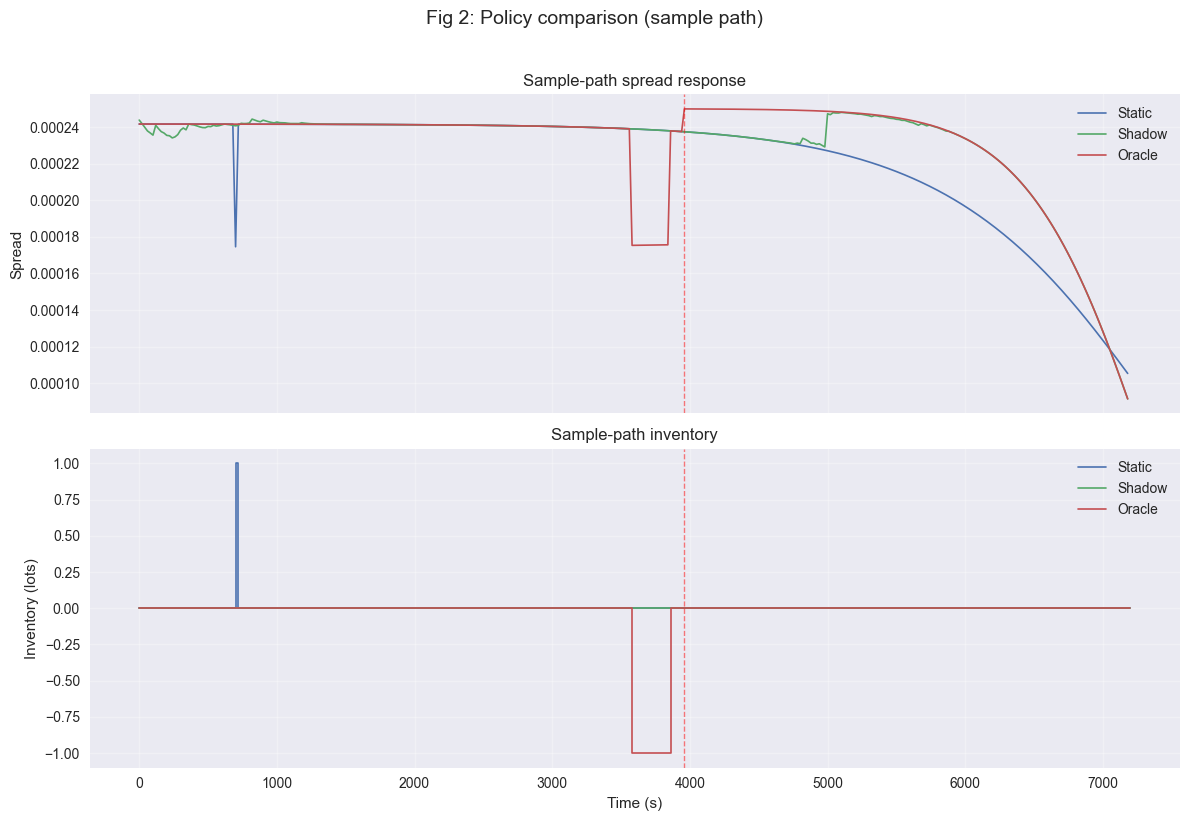

In [8]:

s_stat = res_static["sample"]
s_shad = res_shadow["sample"]
s_orac = res_oracle["sample"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Spread
spread_stat = s_stat["delta_bid"] + s_stat["delta_ask"]
spread_shad = s_shad["delta_bid"] + s_shad["delta_ask"]
spread_orac = s_orac["delta_bid"] + s_orac["delta_ask"]
axes[0].plot(t_mid, spread_stat, lw=1.2, label="Static")
axes[0].plot(t_mid, spread_shad, lw=1.2, label="Shadow")
axes[0].plot(t_mid, spread_orac, lw=1.2, label="Oracle")
axes[0].set_ylabel("Spread"); axes[0].set_title("Sample-path spread response")
axes[0].axvline(times_plot[int(0.55*N_T)], color="red", ls="--", lw=1, alpha=0.5)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Inventory
axes[1].step(times_plot, s_stat["inventory"], where="post", lw=1.2, label="Static")
axes[1].step(times_plot, s_shad["inventory"], where="post", lw=1.2, label="Shadow")
axes[1].step(times_plot, s_orac["inventory"], where="post", lw=1.2, label="Oracle")
axes[1].set_ylabel("Inventory (lots)"); axes[1].set_xlabel("Time (s)")
axes[1].set_title("Sample-path inventory")
axes[1].axvline(times_plot[int(0.55*N_T)], color="red", ls="--", lw=1, alpha=0.5)
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle("Fig 2: Policy comparison (sample path)", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()


## 9. Figure 3 — P&L distributions

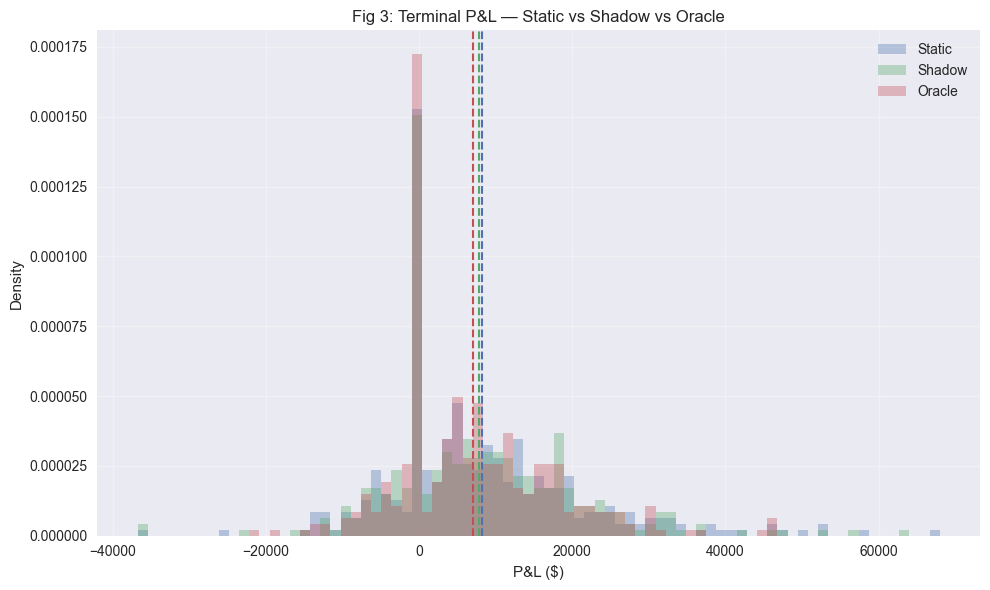

In [9]:

fig, ax = plt.subplots(figsize=(10, 6))
all_pnl = np.concatenate([res_static["pnl"], res_shadow["pnl"], res_oracle["pnl"]])
bins = np.linspace(all_pnl.min(), all_pnl.max(), 80)

ax.hist(res_static["pnl"], bins=bins, density=True, alpha=0.35, label="Static")
ax.hist(res_shadow["pnl"], bins=bins, density=True, alpha=0.35, label="Shadow")
ax.hist(res_oracle["pnl"], bins=bins, density=True, alpha=0.35, label="Oracle")
ax.axvline(np.mean(res_static["pnl"]), color="C0", ls="--", lw=1.5)
ax.axvline(np.mean(res_shadow["pnl"]), color="C1", ls="--", lw=1.5)
ax.axvline(np.mean(res_oracle["pnl"]), color="C2", ls="--", lw=1.5)
ax.set_title("Fig 3: Terminal P&L — Static vs Shadow vs Oracle")
ax.set_xlabel("P&L ($)"); ax.set_ylabel("Density")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 10. Summary

### How the shadow policy works

1. **Before the session**: Precompute one optimal quote table per candidate world.
2. **At each step**: Observe $(\Delta S, f^b, f^a)$ → update posterior $\pi_t(j)$ via Bayes.
3. **Quote**: Blend world-specific quotes using stress-tilted weights $w_j \propto \pi_j \cdot (\sigma_j / \bar{\sigma})^\eta$.

### Key results

| Policy | Knows regime? | Adapts? | Expected Sharpe |
|--------|---------------|---------|-----------------|
| Static | No | No | Baseline |
| Shadow | No — infers via Bayes | Yes — belief-weighted | Intermediate |
| Oracle | Yes (cheats) | Yes — perfect | Upper bound |

The shadow policy should track somewhere between Static and Oracle, demonstrating the **value of online learning** in the Guéant framework.

### Stress distortion ($\eta$)

The parameter $\eta = 1.6$ biases toward conservative (high-vol) worlds. This is a form of **robust control** — the market maker prefers to quote as if conditions are worse than expected, reducing tail risk.
